In [ ]:
import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report, cohen_kappa_score)
 
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()
torch.backends.cudnn.benchmark = True
print("Using device:", DEVICE, " | AMP:", USE_AMP)
 
DATA_DIR = "/kaggle/input/datasets/vibhingupta028/liver-histopathology-fibrosis-ultrasound-images/Dataset/Dataset"
CLASSES = ["F0", "F1", "F2", "F3", "F4"]
NUM_CLASSES = len(CLASSES)
 
IMG_SIZE = 224           
FREQ_IMG_SIZE = 384      
BATCH_SIZE = 32
EPOCHS = 40
PATIENCE = 5
NUM_WORKERS = 2
 
LR = 1e-4
WEIGHT_DECAY = 1e-4
 
PROJ_DIM = 192           
DROPOUT = 0.3
 
W_CE = 1.0            
W_KD = 0.5            
                       
KD_TEMPERATURE = 3.0  
 
TEACHER_CHECKPOINT_PATH = "/kaggle/input/models/siddhartha5356/resnet/pytorch/default/1/resnet50_baseline.pt"
 
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Using device: cuda  | AMP: True


In [ ]:
records = []
for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_dir):
        raise FileNotFoundError(f"Expected class folder not found: {cls_dir}")
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            records.append((os.path.join(cls_dir, fname), cls))
 
df = pd.DataFrame(records, columns=["filepath", "label"])
label2idx = {c: i for i, c in enumerate(CLASSES)}
df["label_idx"] = df["label"].map(label2idx)
 
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label_idx"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label_idx"], random_state=SEED)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
 
class_counts = train_df["label_idx"].value_counts().sort_index().values
class_weights = 1.0 / class_counts

Train: 4426  Val: 948  Test: 949


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
 
class FibrosisDataset(Dataset):
    def __init__(self, dataframe, augment):
        self.df = dataframe.reset_index(drop=True)
        self.augment = augment
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
 
        if self.augment:
            if random.random() < 0.5:
                img = transforms.functional.hflip(img)
            img = transforms.functional.rotate(img, random.uniform(-10, 10))
            img = transforms.ColorJitter(brightness=0.15, contrast=0.15)(img)
 
        spatial_img = transforms.functional.resize(img, (IMG_SIZE, IMG_SIZE))
        spatial_img = transforms.functional.to_tensor(spatial_img)
        spatial_img = transforms.functional.normalize(spatial_img, IMAGENET_MEAN, IMAGENET_STD)
 
        freq_img = transforms.functional.resize(img, (FREQ_IMG_SIZE, FREQ_IMG_SIZE))
        freq_img = transforms.functional.to_grayscale(freq_img, num_output_channels=1)
        freq_img = transforms.functional.to_tensor(freq_img)
 
        return spatial_img, freq_img, int(row["label_idx"])
 
train_ds = FibrosisDataset(train_df, augment=True)
val_ds = FibrosisDataset(val_df, augment=False)
test_ds = FibrosisDataset(test_df, augment=False)
 
sample_weights = train_df["label_idx"].map(lambda i: class_weights[i]).values
sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)
 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [ ]:
class LBPTransform(nn.Module):
    def __init__(self, radii=(1, 2, 3)):
        super().__init__()
        self.radii = radii
 
    @staticmethod
    def _lbp_at_radius(x, r):
        b, c, h, w = x.shape
        xp = F.pad(x, (r, r, r, r), mode="replicate")
        offsets = [(-r, -r), (-r, 0), (-r, r), (0, r),
                   (r, r), (r, 0), (r, -r), (0, -r)]
        center = xp[:, :, r:r + h, r:r + w]
        code = torch.zeros_like(center)
        for k, (dy, dx) in enumerate(offsets):
            neighbor = xp[:, :, r + dy:r + dy + h, r + dx:r + dx + w]
            bit = (neighbor >= center).float()
            code = code + bit * (2 ** k)
        return code / 255.0
 
    def forward(self, x):
        maps = [self._lbp_at_radius(x, r) for r in self.radii]
        return torch.cat(maps, dim=1)   # (B, len(radii), H, W)

In [ ]:

class SmallFreqCNN(nn.Module):
    def __init__(self, in_channels=3, out_dim=96):
        super().__init__()
        self.out_dim = out_dim
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 24, kernel_size=3, padding=1), nn.BatchNorm2d(24), nn.ReLU(inplace=True),
            nn.Conv2d(24, 48, kernel_size=3, padding=1), nn.BatchNorm2d(48), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(48, out_dim, kernel_size=3, padding=1), nn.BatchNorm2d(out_dim), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
 
    def forward(self, x):
        return self.net(x).flatten(1)

In [ ]:
class BasicResBlock(nn.Module):
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
        self.relu = nn.ReLU(inplace=True)
 
        self.shortcut = None
        if stride != 1 or cin != cout:
            self.shortcut = nn.Sequential(
                nn.Conv2d(cin, cout, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(cout),
            )
 
    def forward(self, x):
        identity = x if self.shortcut is None else self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)
 
 
class CompactResNet(nn.Module):
    def __init__(self, out_dim=256, width=32, blocks_per_stage=2):
        super().__init__()
        w = width
        self.stem = nn.Sequential(
            nn.Conv2d(3, w, kernel_size=3, stride=2, padding=1, bias=False),  # 224 -> 112
            nn.BatchNorm2d(w), nn.ReLU(inplace=True),
        )
        self.stage1 = self._make_stage(w, w, blocks_per_stage, stride=1)          # 112 -> 112
        self.stage2 = self._make_stage(w, w * 2, blocks_per_stage, stride=2)      # 112 -> 56
        self.stage3 = self._make_stage(w * 2, w * 4, blocks_per_stage, stride=2)  # 56  -> 28
        self.stage4 = self._make_stage(w * 4, out_dim, blocks_per_stage, stride=2)  # 28 -> 14
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = out_dim
 
    @staticmethod
    def _make_stage(cin, cout, n_blocks, stride):
        layers = [BasicResBlock(cin, cout, stride=stride)]
        for _ in range(n_blocks - 1):
            layers.append(BasicResBlock(cout, cout, stride=1))
        return nn.Sequential(*layers)
 
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return self.pool(x).flatten(1)
 
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [ ]:
def standard_kd_loss(student_ce_logits, teacher_logits, temperature):
    """Classic Hinton KD: KL divergence between softened distributions."""
    student_log_probs = F.log_softmax(student_ce_logits / temperature, dim=1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=1)
    return F.kl_div(student_log_probs, teacher_probs, reduction="batchmean") * (temperature ** 2)

In [ ]:
class StudentDualStreamNet(nn.Module):
    def __init__(self, num_classes=5, proj_dim=192, dropout=0.3):
        super().__init__()
        self.spatial_backbone = CompactResNet(out_dim=256, width=32, blocks_per_stage=2)  # NOT pretrained
        self.lbp = LBPTransform(radii=(1, 2, 3))
        self.freq_cnn = SmallFreqCNN(in_channels=3, out_dim=96)
 
        self.proj_spatial = nn.Sequential(
            nn.Linear(self.spatial_backbone.out_dim, proj_dim), nn.LayerNorm(proj_dim),
            nn.GELU(), nn.Dropout(dropout)
        )
        self.proj_freq = nn.Sequential(
            nn.Linear(self.freq_cnn.out_dim, proj_dim), nn.LayerNorm(proj_dim),
            nn.GELU(), nn.Dropout(dropout)
        )
        self.gate_fc = nn.Linear(proj_dim * 2, proj_dim)
 
        self.ce_head = nn.Linear(proj_dim, num_classes)
 
    def forward(self, spatial_img, freq_img):
        Fs = self.proj_spatial(self.spatial_backbone(spatial_img))
 
        freq_stack = self.lbp(freq_img)
        Ff = self.proj_freq(self.freq_cnn(freq_stack))
 
        g = torch.sigmoid(self.gate_fc(torch.cat([Fs, Ff], dim=1)))
        fused = g * Fs + (1 - g) * Ff
 
        return {"ce_logits": self.ce_head(fused), "gate_mean": g.mean(dim=1)}

In [ ]:
def build_teacher(num_classes, checkpoint_path):
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
 
    state_dict = torch.load(checkpoint_path, map_location=DEVICE)
    if isinstance(state_dict, dict):
        for key in ("state_dict", "model_state_dict"):
            if key in state_dict:
                state_dict = state_dict[key]
                break

    model.load_state_dict(state_dict)
 
    model.to(DEVICE)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model
 
teacher = build_teacher(NUM_CLASSES, TEACHER_CHECKPOINT_PATH)
teacher_params, _ = count_parameters(teacher)
print(f"Teacher (ResNet50) loaded, frozen. Params: {teacher_params:,}")

Teacher (ResNet50) loaded, frozen. Params: 23,518,277


In [ ]:
def compute_losses(outputs, teacher_logits, labels, ce_criterion, w_kd):
    hard_ce = ce_criterion(outputs["ce_logits"], labels)
    if w_kd > 0:
        kd = standard_kd_loss(outputs["ce_logits"], teacher_logits, KD_TEMPERATURE)
    else:
        kd = torch.zeros((), device=labels.device)
    total = W_CE * hard_ce + w_kd * kd
    parts = {"hard_ce": hard_ce.item(), "kd": float(kd)}
    return total, parts
 
 
@torch.no_grad()
def evaluate_epoch(student, teacher, loader, ce_criterion, w_kd):
    student.eval()
    total_loss, correct, total = 0.0, 0, 0
    for spatial_img, freq_img, labels in loader:
        spatial_img, freq_img, labels = spatial_img.to(DEVICE), freq_img.to(DEVICE), labels.to(DEVICE)
 
        teacher_logits = teacher(spatial_img)
        outputs = student(spatial_img, freq_img)
 
        loss, _ = compute_losses(outputs, teacher_logits, labels, ce_criterion, w_kd)
        total_loss += loss.item() * spatial_img.size(0)
 
        preds = outputs["ce_logits"].argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
 
    return total_loss / total, correct / total
 
 
def train_student(student, teacher, w_kd, epochs=EPOCHS, patience=PATIENCE, run_name="run"):
    optimizer = optim.AdamW(student.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
 
    weights_tensor = torch.tensor(class_weights / class_weights.sum() * len(class_weights),
                                   dtype=torch.float32).to(DEVICE)
    ce_criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
 
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state, epochs_no_improve, stopped_epoch = 0.0, copy.deepcopy(student.state_dict()), 0, epochs
 
    for epoch in range(epochs):
        student.train()
        running_loss = 0.0
        for spatial_img, freq_img, labels in train_loader:
            spatial_img, freq_img, labels = spatial_img.to(DEVICE), freq_img.to(DEVICE), labels.to(DEVICE)
 
            with torch.no_grad():
                teacher_logits = teacher(spatial_img)
 
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = student(spatial_img, freq_img)
                loss, parts = compute_losses(outputs, teacher_logits, labels, ce_criterion, w_kd)
 
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * spatial_img.size(0)
 
        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_acc = evaluate_epoch(student, teacher, val_loader, ce_criterion, w_kd)
        scheduler.step(val_acc)
 
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
 
        print(f"[{run_name}] Epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  "
              f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  "
              f"[last batch: hard_ce={parts['hard_ce']:.3f} kd={parts['kd']:.3f}]")
 
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(student.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                stopped_epoch = epoch + 1
                print(f"[{run_name}] Early stopping at epoch {stopped_epoch}. Best val_acc={best_val_acc:.4f}")
                break
 
    student.load_state_dict(best_state)
    history["stopped_epoch"] = stopped_epoch
    return student, history, best_val_acc
 
 
@torch.no_grad()
def full_test_evaluation(student, loader, run_name="run"):
    student.eval()
    all_labels, all_preds = [], []
    for spatial_img, freq_img, labels in loader:
        spatial_img, freq_img = spatial_img.to(DEVICE), freq_img.to(DEVICE)
        outputs = student(spatial_img, freq_img)
        all_preds.append(outputs["ce_logits"].argmax(dim=1).cpu())
        all_labels.append(labels)
 
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
 
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "quadratic_weighted_kappa": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "mean_absolute_error": float(np.mean(np.abs(y_true - y_pred))),
    }
    print(f"\n=== [{run_name}] Test set results ===")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    print(f"\n=== [{run_name}] Classification report ===")
    print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0))
 
    cm = confusion_matrix(y_true, y_pred)
    return y_true, y_pred, cm, metrics

Student params: 2,991,653  (12.7% of teacher size)

RUN 1/2: BASELINE — hard-label CE only, NO distillation (w_kd=0)


/tmp/ipykernel_58/3265043545.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_58/3265043545.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


[baseline] Epoch 1/40  train_loss=1.2623  val_loss=1.2058  val_acc=0.3576  [last batch: hard_ce=1.332 kd=0.000]
[baseline] Epoch 2/40  train_loss=1.1485  val_loss=1.1126  val_acc=0.5939  [last batch: hard_ce=1.449 kd=0.000]
[baseline] Epoch 3/40  train_loss=1.0481  val_loss=1.0050  val_acc=0.5897  [last batch: hard_ce=0.803 kd=0.000]
[baseline] Epoch 4/40  train_loss=0.9755  val_loss=1.0096  val_acc=0.5812  [last batch: hard_ce=0.698 kd=0.000]
[baseline] Epoch 5/40  train_loss=0.9202  val_loss=1.0340  val_acc=0.5633  [last batch: hard_ce=0.824 kd=0.000]
[baseline] Epoch 6/40  train_loss=0.8108  val_loss=0.7818  val_acc=0.7078  [last batch: hard_ce=0.838 kd=0.000]
[baseline] Epoch 7/40  train_loss=0.7468  val_loss=0.8017  val_acc=0.6973  [last batch: hard_ce=1.151 kd=0.000]
[baseline] Epoch 8/40  train_loss=0.6874  val_loss=0.6825  val_acc=0.7616  [last batch: hard_ce=0.410 kd=0.000]
[baseline] Epoch 9/40  train_loss=0.6609  val_loss=0.6242  val_acc=0.8038  [last batch: hard_ce=0.685 kd

/tmp/ipykernel_58/3265043545.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_58/3265043545.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_58/3265043545.py:11: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  parts = {"hard_ce": hard_ce.item(), "kd": float(kd)}


[distilled] Epoch 1/40  train_loss=5.2262  val_loss=4.8056  val_acc=0.4399  [last batch: hard_ce=1.419 kd=7.338]
[distilled] Epoch 2/40  train_loss=4.5668  val_loss=4.1723  val_acc=0.5928  [last batch: hard_ce=1.299 kd=8.894]
[distilled] Epoch 3/40  train_loss=4.0112  val_loss=3.6308  val_acc=0.6139  [last batch: hard_ce=0.673 kd=4.529]
[distilled] Epoch 4/40  train_loss=3.6433  val_loss=4.2889  val_acc=0.5200  [last batch: hard_ce=0.452 kd=3.535]
[distilled] Epoch 5/40  train_loss=3.4932  val_loss=3.9795  val_acc=0.5728  [last batch: hard_ce=0.853 kd=4.397]
[distilled] Epoch 6/40  train_loss=3.1053  val_loss=2.9614  val_acc=0.6878  [last batch: hard_ce=0.880 kd=5.043]
[distilled] Epoch 7/40  train_loss=2.9219  val_loss=2.5616  val_acc=0.7310  [last batch: hard_ce=1.403 kd=4.233]
[distilled] Epoch 8/40  train_loss=2.7593  val_loss=2.3048  val_acc=0.7690  [last batch: hard_ce=0.197 kd=3.505]
[distilled] Epoch 9/40  train_loss=2.6155  val_loss=1.9933  val_acc=0.8186  [last batch: hard_ce

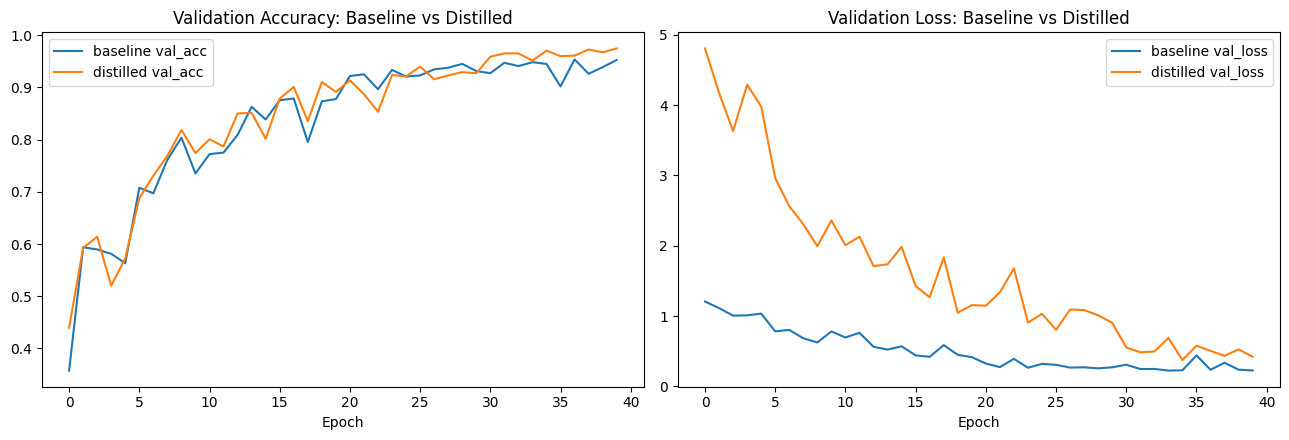

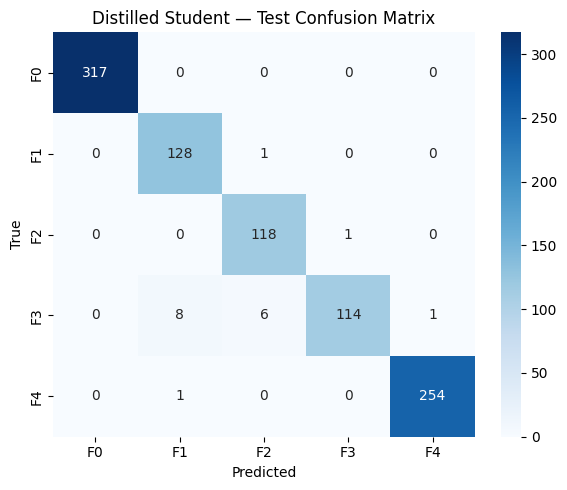

In [ ]:

def make_student():
    torch.manual_seed(SEED)
    return StudentDualStreamNet(num_classes=NUM_CLASSES, proj_dim=PROJ_DIM, dropout=DROPOUT).to(DEVICE)
 
student_params, _ = count_parameters(make_student())
print(f"Student params: {student_params:,}  ({student_params / teacher_params:.1%} of teacher size)")
 
print("\n" + "=" * 70)
print("RUN 1/2: BASELINE — hard-label CE only, NO distillation (w_kd=0)")
print("=" * 70)
baseline_student = make_student()
baseline_student, baseline_history, baseline_val_acc = train_student(
    baseline_student, teacher, w_kd=0.0, run_name="baseline"
)
_, _, _, baseline_test_metrics = full_test_evaluation(baseline_student, test_loader, run_name="baseline")
 
print("\n" + "=" * 70)
print(f"RUN 2/2: DISTILLED — hard-label CE + standard KD (w_kd={W_KD})")
print("=" * 70)
distilled_student = make_student()
distilled_student, distilled_history, distilled_val_acc = train_student(
    distilled_student, teacher, w_kd=W_KD, run_name="distilled"
)
_, _, distilled_cm, distilled_test_metrics = full_test_evaluation(distilled_student, test_loader, run_name="distilled")


=== Distillation impact: baseline vs distilled (test set) ===
                  accuracy  macro_f1  quadratic_weighted_kappa  \
baseline (no KD)    0.9715    0.9607                    0.9846   
distilled (KD)      0.9810    0.9720                    0.9901   

                  mean_absolute_error  accuracy_gain_vs_baseline  
baseline (no KD)               0.0443                     0.0000  
distilled (KD)                 0.0295                     0.0095  


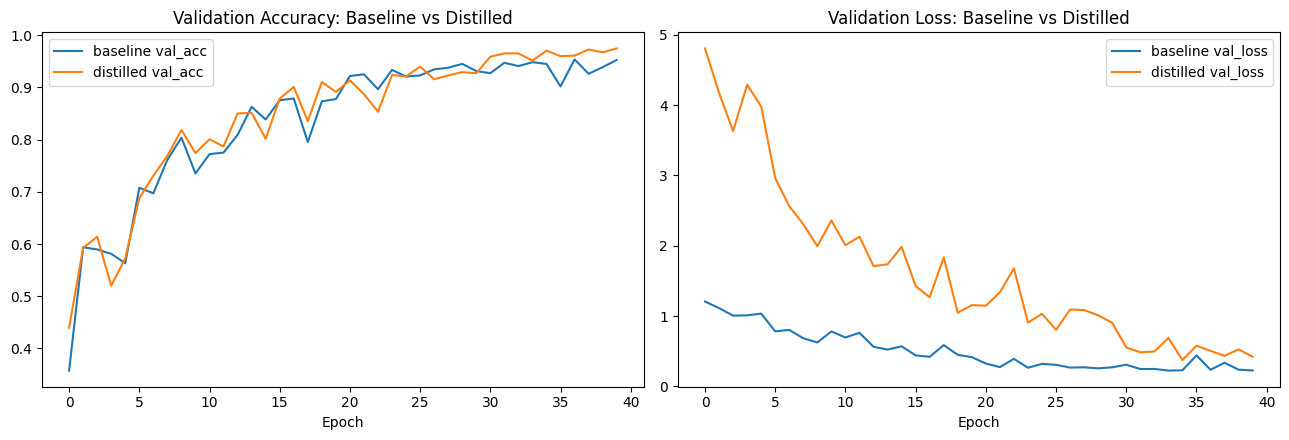

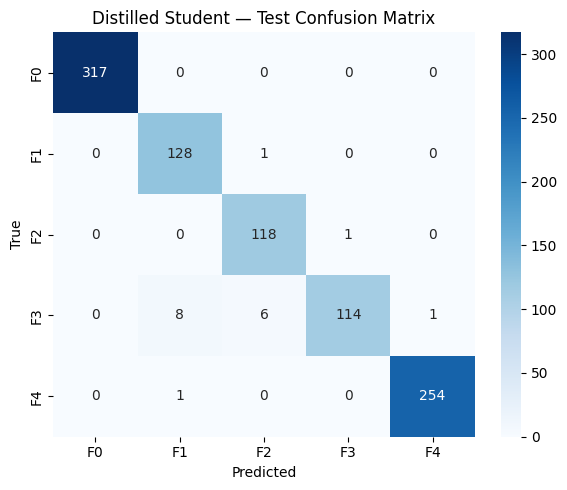

In [ ]:
comparison_df = pd.DataFrame({
    "baseline (no KD)": baseline_test_metrics,
    "distilled (KD)": distilled_test_metrics,
}).T
comparison_df["accuracy_gain_vs_baseline"] = comparison_df["accuracy"] - baseline_test_metrics["accuracy"]
print("\n=== Distillation impact: baseline vs distilled (test set) ===")
print(comparison_df.round(4))
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(baseline_history["val_acc"], label="baseline val_acc")
axes[0].plot(distilled_history["val_acc"], label="distilled val_acc")
axes[0].set_title("Validation Accuracy: Baseline vs Distilled")
axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(baseline_history["val_loss"], label="baseline val_loss")
axes[1].plot(distilled_history["val_loss"], label="distilled val_loss")
axes[1].set_title("Validation Loss: Baseline vs Distilled")
axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "baseline_vs_distilled_curves.png"), dpi=150)
plt.show()
 
plt.figure(figsize=(6, 5))
sns.heatmap(distilled_cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Distilled Student — Test Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "distilled_student_confusion_matrix.png"), dpi=150)
plt.show()


In [ ]:
@torch.no_grad()
def benchmark_latency(model, forward_fn, n_warmup=10, n_runs=100, device=torch.device("cpu")):
    model = model.to(device).eval()
    dummy_spatial = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    dummy_freq = torch.randn(1, 1, FREQ_IMG_SIZE, FREQ_IMG_SIZE, device=device)
    for _ in range(n_warmup):
        forward_fn(model, dummy_spatial, dummy_freq)
    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.time()
    for _ in range(n_runs):
        forward_fn(model, dummy_spatial, dummy_freq)
    if device.type == "cuda":
        torch.cuda.synchronize()
    return (time.time() - start) / n_runs * 1000   # ms/image
 
def _teacher_forward(m, spatial_img, freq_img):
    return m(spatial_img)
 
def _student_forward(m, spatial_img, freq_img):
    return m(spatial_img, freq_img)
 
cpu = torch.device("cpu")
teacher_cpu_ms = benchmark_latency(teacher, _teacher_forward, device=cpu)
student_cpu_ms = benchmark_latency(distilled_student, _student_forward, device=cpu)
teacher.to(DEVICE)  # move back after CPU benchmark
 
efficiency_df = pd.DataFrame({
    "model": ["teacher (ResNet50)", "student (CompactResNet+LBP)"],
    "params": [teacher_params, student_params],
    "params_pct_of_teacher": [1.0, student_params / teacher_params],
    "cpu_latency_ms": [teacher_cpu_ms, student_cpu_ms],
}).round(4)
print("\n=== Efficiency comparison ===")
print(efficiency_df)
 


=== Efficiency comparison ===
                         model    params  params_pct_of_teacher  \
0           teacher (ResNet50)  23518277                 1.0000   
1  student (CompactResNet+LBP)   2991653                 0.1272   

   cpu_latency_ms  
0         78.4634  
1        137.3105  


In [ ]:
torch.save(baseline_student.state_dict(), os.path.join(OUTPUT_DIR, "baseline_student_no_kd.pt"))
torch.save(distilled_student.state_dict(), os.path.join(OUTPUT_DIR, "distilled_student.pt"))
comparison_df.to_csv(os.path.join(OUTPUT_DIR, "baseline_vs_distilled_results.csv"))
efficiency_df.to_csv(os.path.join(OUTPUT_DIR, "student_efficiency.csv"), index=False)
print("\nSaved both student checkpoints and comparison CSVs to", OUTPUT_DIR)


Saved both student checkpoints and comparison CSVs to /kaggle/working
